In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
df=pd.read_csv("Rajshahi-Srimongals.csv")
df=df[df["Year"]<2019]

# Basic Info. From Dataset

In [3]:
df.head(10)

,Unnamed: 0,Region,Year,Month,Date,ST-10,ST-30,ST-50,Temperature,Years
0,0,Srimongal,2001,1,1,21.75,22.20,22.10,18.0,2001-01-01
1,1,Srimongal,2001,1,2,22.90,22.55,22.25,18.6,2001-01-01
2,2,Srimongal,2001,1,3,22.50,22.60,22.40,19.4,2001-01-01
3,3,Srimongal,2001,1,4,22.05,22.50,22.50,19.0,2001-01-01
4,4,Srimongal,2001,1,5,20.40,21.70,22.20,16.4,2001-01-01
5,5,Srimongal,2001,1,6,19.80,20.70,21.60,14.0,2001-01-01
6,6,Srimongal,2001,1,7,18.90,20.10,21.20,12.7,2001-01-01
7,7,Srimongal,2001,1,8,18.90,20.05,20.85,12.8,2001-01-01
8,8,Srimongal,2001,1,9,18.70,19.90,20.30,13.5,2001-01-01
9,9,Srimongal,2001,1,10,19.50,20.30,20.60,15.2,2001-01-01


In [4]:
df.shape

(13148, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13148 entries, 0 to 14608
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   13148 non-null  int64  
 1   Region       13148 non-null  object 
 2   Year         13148 non-null  int64  
 3   Month        13148 non-null  int64  
 4   Date         13148 non-null  int64  
 5   ST-10        13148 non-null  float64
 6   ST-30        13148 non-null  float64
 7   ST-50        13148 non-null  float64
 8   Temperature  13148 non-null  float64
 9   Years        13148 non-null  object 
dtypes: float64(4), int64(4), object(2)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()  

Unnamed: 0     0
Region         0
Year           0
Month          0
Date           0
ST-10          0
ST-30          0
ST-50          0
Temperature    0
Years          0
dtype: int64

In [7]:
df.describe()

,Unnamed: 0,Year,Month,Date,ST-10,ST-30,ST-50,Temperature
count,13148.000000,13148.000000,13148.000000,13148.000000,13148.000000,13148.000000,13148.000000,13148.000000
mean,7304.000000,2009.500304,6.523654,15.728628,27.176202,27.429538,27.102829,24.835625
std,4443.339298,5.187934,3.448848,8.800000,4.767962,4.404951,4.046989,4.837913
min,0.000000,2001.000000,1.000000,1.000000,14.300000,15.600000,15.550000,8.500000
25%,3286.750000,2005.000000,4.000000,8.000000,23.250000,23.800000,23.700000,21.000000
50%,7304.000000,2009.500000,7.000000,16.000000,28.750000,29.000000,28.500000,26.500000
75%,11321.250000,2014.000000,10.000000,23.000000,30.950000,31.000000,30.400000,28.600000
max,14608.000000,2018.000000,12.000000,31.000000,38.000000,36.800000,36.300000,34.800000


In [8]:
df.duplicated().sum()

0

In [9]:
df.groupby('Region')[['Temperature','ST-10','ST-30','ST-50']].max()

,Temperature,ST-10,ST-30,ST-50
Region,,,,
Rajshahi,34.8,38.0,36.80,36.30
Srimongal,32.4,34.4,33.25,34.51


In [10]:
df.groupby('Region')['Temperature'].min()

Region
Rajshahi     10.0
Srimongal     8.5
Name: Temperature, dtype: float64

In [11]:
df.columns

Index(['Unnamed: 0', 'Region', 'Year', 'Month', 'Date', 'ST-10', 'ST-30',
       'ST-50', 'Temperature', 'Years'],
      dtype='object')

In [12]:
x=df[['Region', 'Temperature', 'ST-10', 'ST-30', 'ST-50']]

In [13]:
x.sample()

,Region,Temperature,ST-10,ST-30,ST-50
3875,Srimongal,28.0,31.4,30.4,29.8


In [14]:
x.groupby('Region').corr()['Temperature']

Region                
Rajshahi   Temperature    1.000000
           ST-10          0.972189
           ST-30          0.958647
           ST-50          0.941273
Srimongal  Temperature    1.000000
           ST-10          0.964532
           ST-30          0.963529
           ST-50          0.940838
Name: Temperature, dtype: float64

# Preprocessing

In [15]:
df.dtypes

Unnamed: 0       int64
Region          object
Year             int64
Month            int64
Date             int64
ST-10          float64
ST-30          float64
ST-50          float64
Temperature    float64
Years           object
dtype: object

In [16]:
df['Years'] = pd.to_datetime(df['Year'], format='%Y')

In [17]:
df['Years'].value_counts()

Years
2004-01-01    732
2016-01-01    732
2008-01-01    732
2012-01-01    732
2001-01-01    730
2011-01-01    730
2017-01-01    730
2015-01-01    730
2014-01-01    730
2013-01-01    730
2010-01-01    730
2002-01-01    730
2009-01-01    730
2007-01-01    730
2006-01-01    730
2005-01-01    730
2003-01-01    730
2018-01-01    730
Name: count, dtype: int64

In [18]:
df.sample()

,Unnamed: 0,Region,Year,Month,Date,ST-10,ST-30,ST-50,Temperature,Years
11529,11529,Rajshahi,2010,7,27,32.4,31.7,32.1,27.9,2010-01-01


# EDA

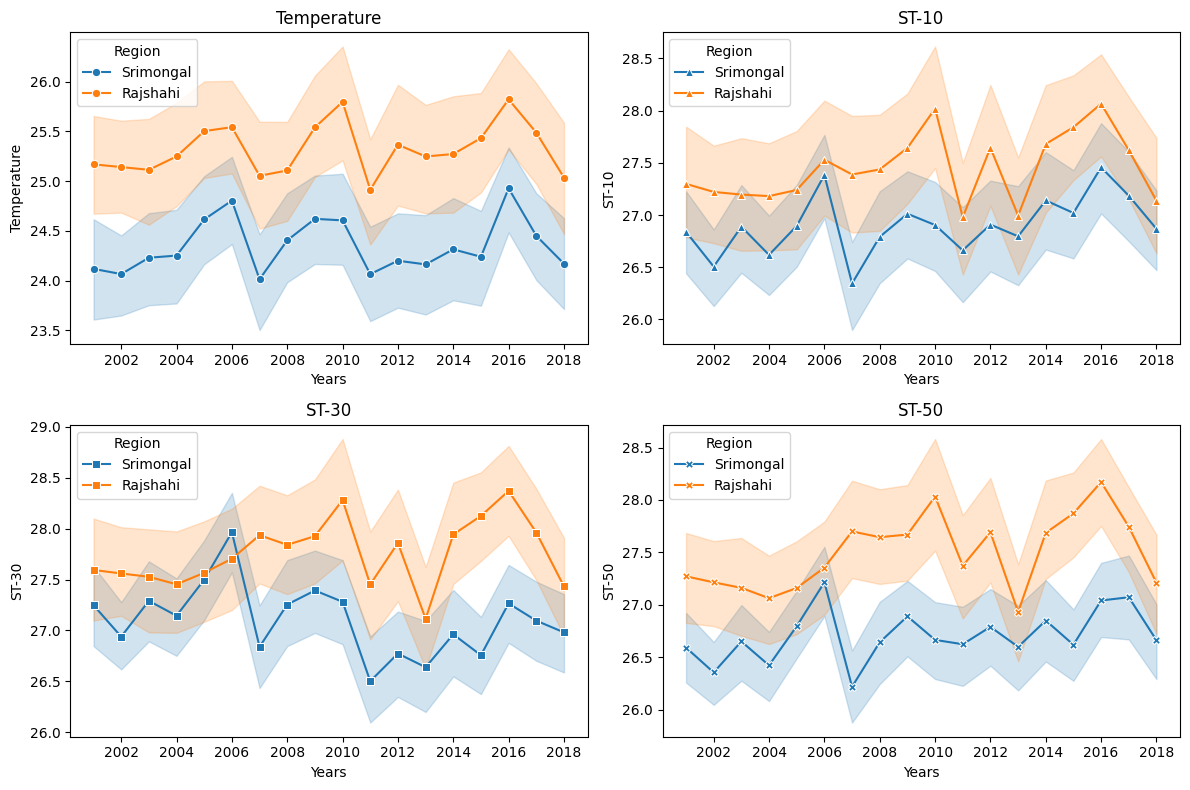

In [19]:


plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.lineplot(x='Years', y='Temperature', hue='Region', marker='o', data=df)
plt.title("Temperature")

plt.subplot(2, 2, 2)
sns.lineplot(x='Years', y='ST-10', hue='Region', marker='^', data=df)
plt.title("ST-10")

plt.subplot(2, 2, 3)
sns.lineplot(x='Years', y='ST-30', hue='Region', marker='s', data=df)
plt.title("ST-30")

plt.subplot(2, 2, 4)
sns.lineplot(x='Years', y='ST-50', hue='Region', marker='X', data=df)
plt.title("ST-50")


plt.tight_layout()
plt.show()


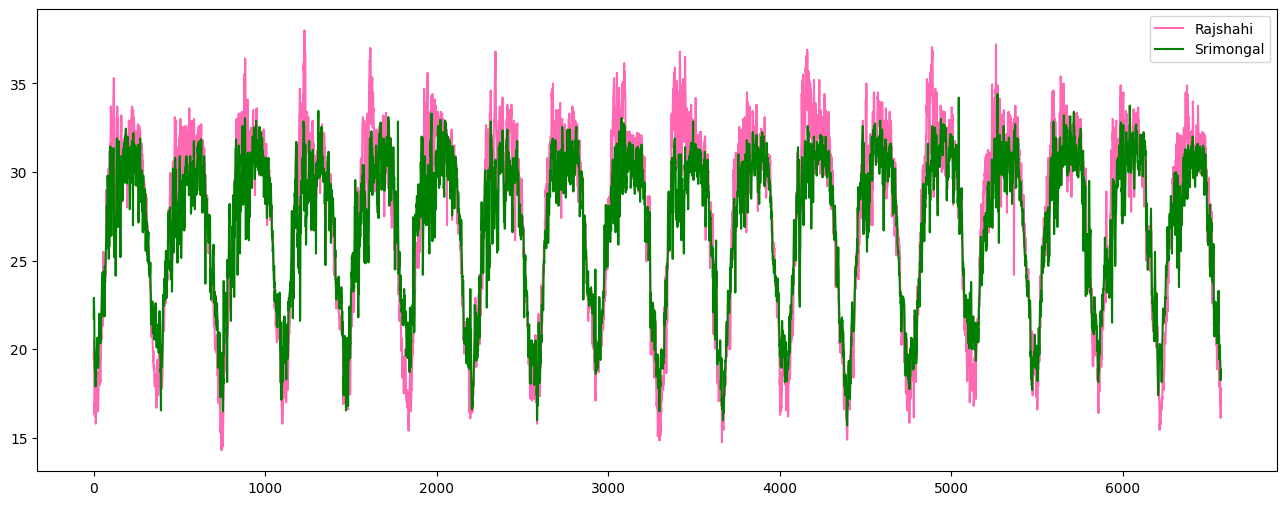

In [20]:
plt.figure(figsize=(16,6)) 
plt.plot(df[df['Region']=='Rajshahi']['ST-10'].values, color='hotpink', label='Rajshahi') 
plt.plot(df[df['Region']=='Srimongal']['ST-10'].values, color='green', label='Srimongal')
plt.legend()

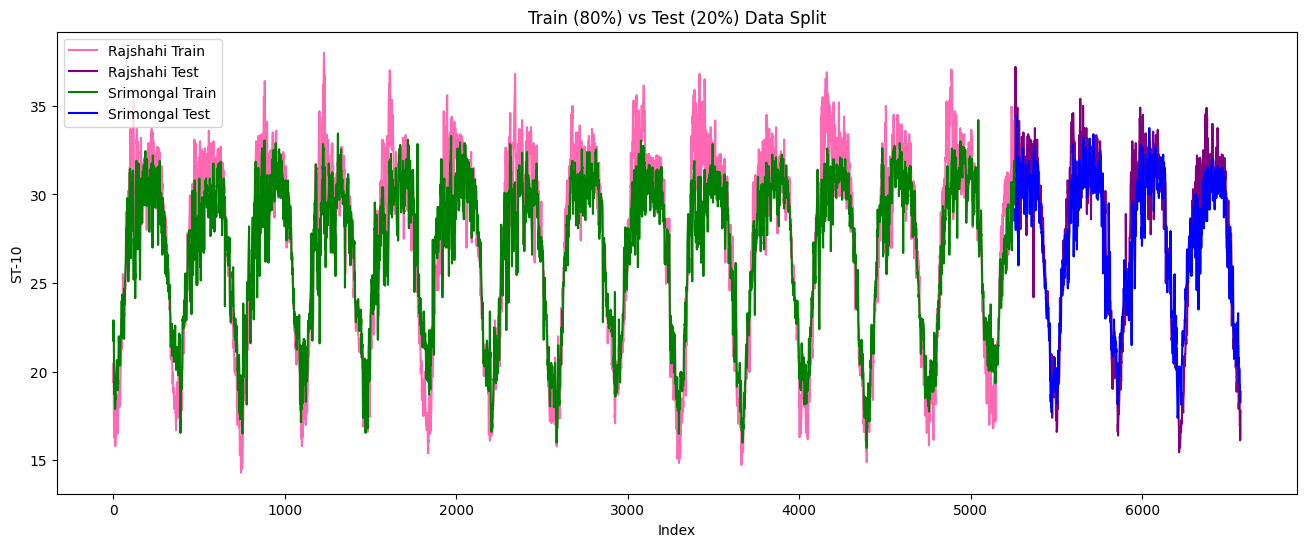

In [21]:
plt.figure(figsize=(16,6))

# Rajshahi
raj = df[df['Region']=='Rajshahi']['ST-10'].values
split_raj = int(len(raj) * 0.8)

plt.plot(raj[:split_raj], color='hotpink', label='Rajshahi Train')
plt.plot(range(split_raj, len(raj)), raj[split_raj:], color='purple', label='Rajshahi Test')

# Srimongal
sri = df[df['Region']=='Srimongal']['ST-10'].values
split_sri = int(len(sri) * 0.8)

plt.plot(sri[:split_sri], color='green', label='Srimongal Train')
plt.plot(range(split_sri, len(sri)), sri[split_sri:], color='blue', label='Srimongal Test')

plt.legend()
plt.title("Train (80%) vs Test (20%) Data Split")
plt.xlabel("Index")
plt.ylabel("ST-10")
plt.show()


In [22]:
y=df[df['Region']=='Rajshahi']
z=df[df['Region']=='Srimongal']


<Axes: xlabel='ST-50', ylabel='Temperature'>

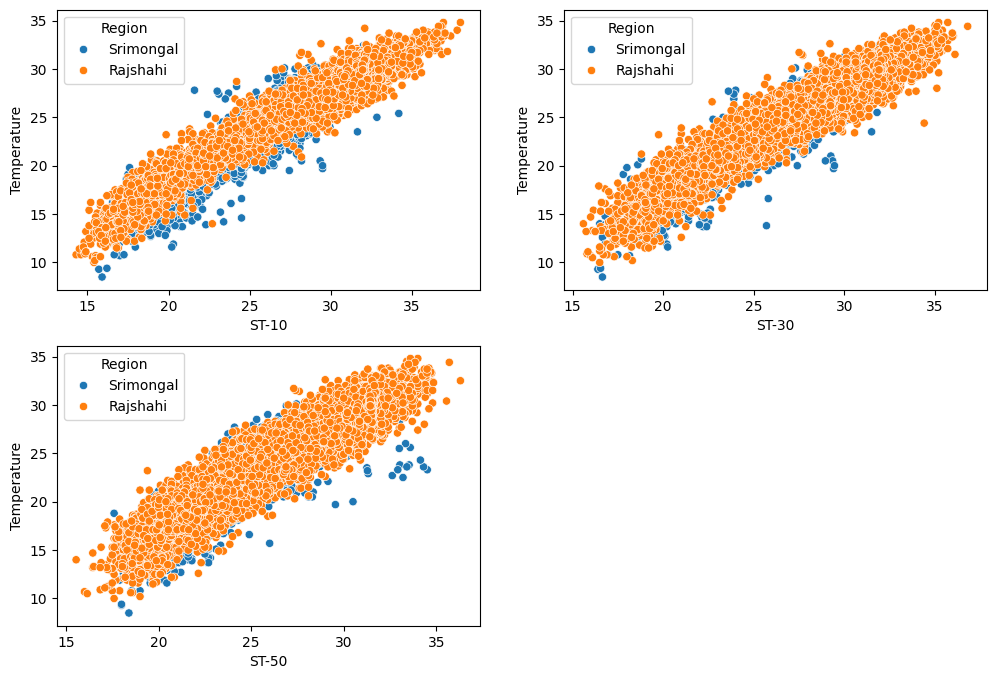

In [23]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.scatterplot(x='ST-10',y='Temperature',hue='Region',data=df)

plt.subplot(2, 2, 2)
sns.scatterplot(x='ST-30',y='Temperature',hue='Region',data=df)

plt.subplot(2, 2, 3)
sns.scatterplot(x='ST-50',y='Temperature',hue='Region',data=df)


<Axes: xlabel='Region', ylabel='ST-50'>

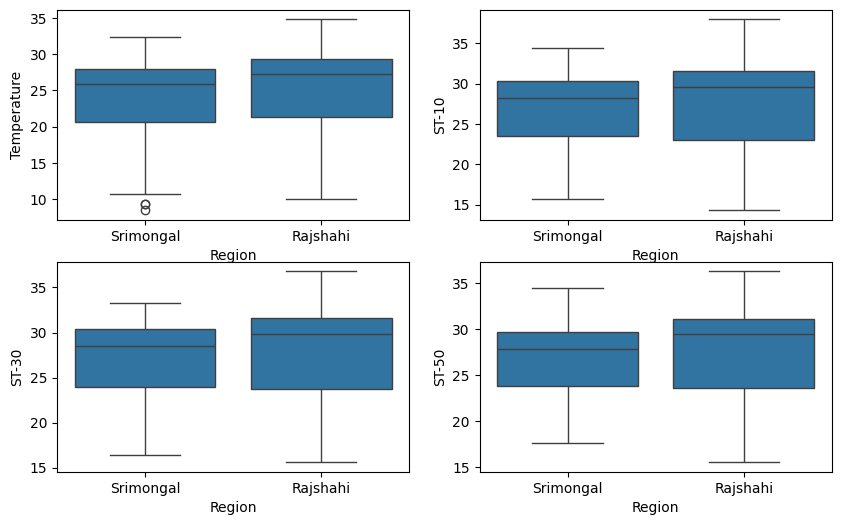

In [24]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
sns.boxplot(x='Region',y='Temperature',data=df)

plt.subplot(2,2,2)
sns.boxplot(x='Region',y='ST-10',data=df)

plt.subplot(2,2,3)
sns.boxplot(x='Region',y='ST-30',data=df)

plt.subplot(2,2,4)
sns.boxplot(x='Region',y='ST-50',data=df)

<Axes: >

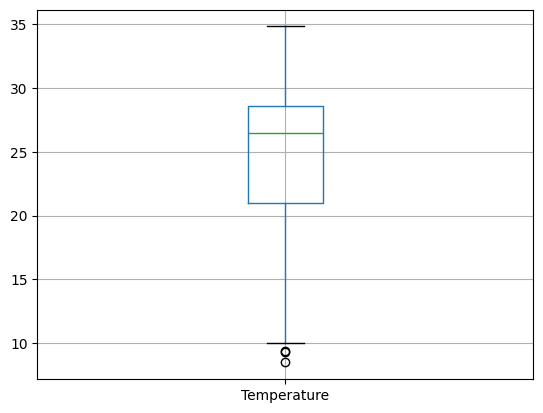

In [25]:
df.boxplot('Temperature')

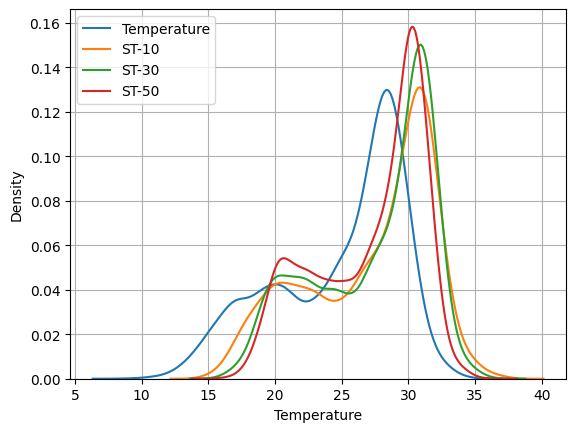

In [26]:
sns.kdeplot(df['Temperature'], label='Temperature', fill=False)
sns.kdeplot(df['ST-10'], label='ST-10', fill=False)
sns.kdeplot(df['ST-30'], label='ST-30', fill=False)
sns.kdeplot(df['ST-50'], label='ST-50', fill=False)
plt.grid()
plt.legend()

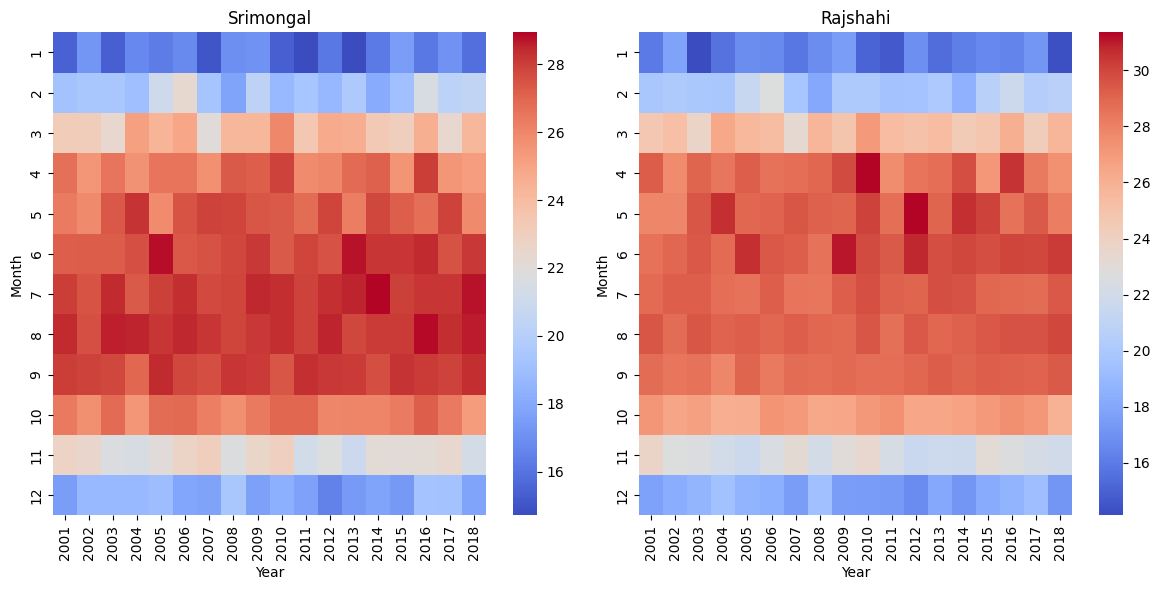

In [27]:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(df[df['Region']=='Srimongal'].pivot_table(values='Temperature', index='Month', columns='Year'), cmap='coolwarm')
plt.title('Srimongal')

plt.subplot(1, 2, 2)
sns.heatmap(df[df['Region']=='Rajshahi'].pivot_table(values='Temperature', index='Month', columns='Year'), cmap='coolwarm')
plt.title('Rajshahi')

plt.tight_layout()



# What's Wrong with ST-10 at Srimongal in Recent Years🤦‍♂️🤷‍♂️

In [28]:
dff=df.copy()
dff=dff[(dff["Year"]<=2022) & (dff["Year"]>2021)]
dff.head()

,Unnamed: 0,Region,Year,Month,Date,ST-10,ST-30,ST-50,Temperature,Years


In [29]:
dff.shape

(0, 10)

In [30]:
y=dff[['Region', 'Temperature', 'ST-10', 'ST-30', 'ST-50']]
y.groupby('Region').corr()['Temperature']

Series([], Name: Temperature, dtype: float64)

In [31]:
y.groupby('Region')['ST-10'].describe()


,count,mean,std,min,25%,50%,75%,max


In [32]:
y.groupby('Region')['Temperature'].describe()

,count,mean,std,min,25%,50%,75%,max


In [33]:
y.groupby('Region').plot(kind='line')

,Region,Temperature,ST-10,ST-30,ST-50
Region,,,,,


# Model Selection

In [34]:
data=df.copy()
data=data[data["Year"]<2019]
data_raj=data[data['Region']=='Rajshahi']
data_sri=data[data['Region']=='Srimongal']


In [35]:
df_raj=data_raj[['Temperature', 'ST-10', 'ST-30', 'ST-50']]
df_sri=data_sri[['Temperature', 'ST-10', 'ST-30', 'ST-50']]

In [36]:
df_sri.sample()

,Temperature,ST-10,ST-30,ST-50
5629,26.4,29.1,28.95,23.9


# Rajshahi Linear Regression

In [64]:
import math 



n=len(df_raj)

train_end=math.floor(n*0.85)


train_raj=df_raj.iloc[:train_end]
val_raj=df_raj.iloc[train_end:]

X_train_raj=train_raj[['Temperature']]
y_train_raj=train_raj[['ST-10']]

X_val_raj=val_raj[['Temperature']]
y_val_raj=val_raj[['ST-10']]


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


In [39]:
lr_raj=LinearRegression()
lr_raj.fit(X_train_raj,y_train_raj)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_raj_pred=lr_raj.predict(X_val_raj)
mae_raj=round(mean_absolute_error(y_val_raj,y_raj_pred),3)
mse_raj=mean_squared_error(y_val_raj,y_raj_pred)
rmse_raj=round(mse_raj**0.5,3)
r2_raj=round(r2_score(y_val_raj,y_raj_pred),2)


print("\nRAJSHAHI\n")
print(f"MAE: {mae_raj}\nRMSE: {rmse_raj}\nR2 SCORE: {r2_raj}")


RAJSHAHI

MAE: 0.934
RMSE: 1.216
R2 SCORE: 0.94


In [41]:
m_raj=lr_raj.coef_[0][0]
m_raj

1.0272828721685576

In [42]:
c_raj=lr_raj.intercept_[0]
c_raj

1.4157943239970905

C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_24848\2140514160.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_raj.min(), y_val_raj.max()],


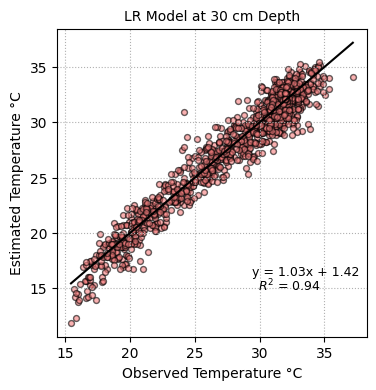

In [43]:
y_val_rajj= y_val_raj[400:1200]
y_raj_predd = y_raj_pred[400:1200]
plt.figure(figsize=(4,4))
plt.scatter(y_val_raj, y_raj_pred,s=18, c='#f57e7e', alpha=0.6, edgecolors='black',marker='o')
plt.plot([y_val_raj.min(), y_val_raj.max()],
         [y_val_raj.min(), y_val_raj.max()],
         'r-', lw=1.5, label="1:1 line",c='black')

x_vals = np.linspace(y_val_raj.min(), y_val_raj.max(), 100)
#plt.plot(x_vals, m_raj * x_vals + c_raj, 'b-', lw=2, label="Best fit line",c='#320d3e')

plt.text(0.63, 0.2, f'y = {m_raj:.2f}x + {c_raj:.2f}', transform=plt.gca().transAxes, fontsize=9)
plt.text(0.65, 0.15, f'$R^2$ = {r2_raj:.2f}', transform=plt.gca().transAxes, fontsize=9)

plt.xlabel('Observed Temperature °C', fontsize=10)
plt.ylabel('Estimated Temperature °C', fontsize=10)
plt.title('LR Model at 30 cm Depth', fontsize=10)
plt.grid(ls=':')
plt.show()

# Srimongal Linear Regression 

In [78]:
import math

m = len(df_sri)

train_end_sri = math.floor(m * 0.80)
train_sri = df_sri.iloc[:train_end_sri]
val_sri = df_sri.iloc[train_end_sri:]


In [79]:
val_sri.shape

(1315, 4)

In [80]:
X_train_sri = train_sri[['Temperature']]
y_train_sri = train_sri[['ST-10']]

X_val_sri = val_sri[['Temperature']]
y_val_sri = val_sri[['ST-10']]


Region
Rajshahi     Axes(0.125,0.11;0.775x0.77)
Srimongal    Axes(0.125,0.11;0.775x0.77)
Name: ST-10, dtype: object

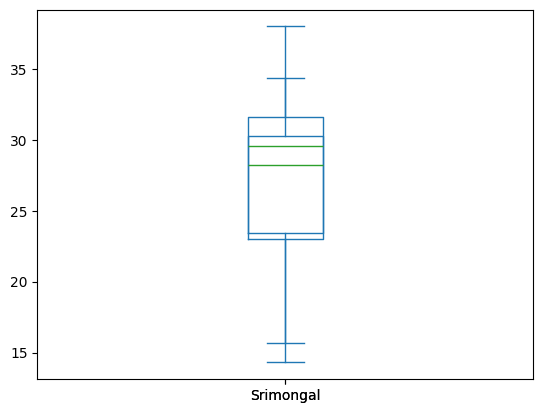

In [81]:
df.groupby('Region')['ST-10'].plot(kind='box')

In [82]:
Q1 = X_train_sri['Temperature'].quantile(0.25)
Q3 = X_train_sri['Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_24848\970763780.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


In [83]:
X_train_sri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5259 entries, 0 to 5258
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  5259 non-null   float64
dtypes: float64(1)
memory usage: 82.2 KB


In [84]:
lr_sri = LinearRegression()
lr_sri.fit(X_train_sri, y_train_sri)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [85]:
y_sri_pred=lr_sri.predict(X_val_sri)
mae_sri=round(mean_absolute_error(y_val_sri,y_sri_pred),3)
mse_sri=mean_squared_error(y_val_sri,y_sri_pred)
rmse_sri=round(mse_sri**0.5,3)
r2_sri=round(r2_score(y_val_sri,y_sri_pred),2)


print("\nSRIMONGAL\n")
print(f"MAE: {mae_sri}\nRMSE: {rmse_sri}\nR2 SCORE: {r2_sri}")


SRIMONGAL

MAE: 0.843
RMSE: 1.192
R2 SCORE: 0.91


In [86]:
m_sri=lr_sri.coef_[0][0]
m_sri

0.8765984673973892

In [73]:
c_sri=lr_sri.intercept_[0]
c_sri

5.477988122416953

In [87]:
len(y_val_sri),len(y_sri_pred)

(1315, 1315)

In [75]:
y_val_sri = np.ravel(y_val_sri)     
y_sri_pred = np.ravel(y_sri_pred)
prediction = pd.DataFrame({
    'Observed': y_val_sri,
    'Estimated': y_sri_pred,
    'Error': y_val_sri - y_sri_pred,
    'Absolute_Error': abs(y_val_sri - y_sri_pred)
})
prediction.head(10)

,Observed,Estimated,Error,Absolute_Error
0,29.60,31.385350,-1.785350,1.785350
1,29.70,31.034064,-1.334064,1.334064
2,29.75,30.419313,-0.669313,0.669313
3,29.30,30.331491,-1.031491,1.031491
4,30.00,32.087922,-2.087922,2.087922
5,31.00,32.966138,-1.966138,1.966138
6,30.90,30.507134,0.392866,0.392866
7,30.40,30.682777,-0.282777,0.282777
8,30.90,30.858421,0.041579,0.041579
9,32.85,30.682777,2.167223,2.167223


In [76]:
prediction.describe()

,Observed,Estimated,Error,Absolute_Error
count,987.000000,987.000000,987.000000,987.000000
mean,27.537153,27.273485,0.263667,0.860046
std,3.973534,3.742436,1.215732,0.898424
min,17.400000,15.665290,-6.804562,0.001015
25%,24.435000,24.096160,-0.264822,0.274357
50%,28.900000,28.662881,0.278903,0.612762
75%,30.800000,30.331491,0.896766,1.163506
max,33.750000,33.932175,6.721163,6.804562


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_24848\116583248.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_sri.min(), y_val_sri.max()],


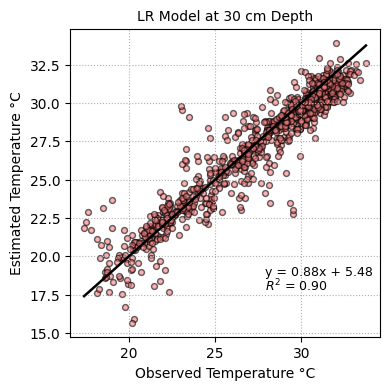

In [77]:

plt.figure(figsize=(4,4))
plt.scatter(y_val_sri, y_sri_pred,s=18, c='#f57e7e', alpha=0.6, edgecolors='black',marker='o')
plt.plot([y_val_sri.min(), y_val_sri.max()],
         [y_val_sri.min(), y_val_sri.max()],
         'r-', lw=1.8, label="1:1 line",c='BLACK')

x_vals_sri = np.linspace(y_val_sri.min(), y_val_sri.max(), 100)
#plt.plot(x_vals_sri, m_sri * x_vals_sri + c_sri, 'b-', lw=2, label="Best fit line" ,c='#320d3e')

plt.text(0.63, 0.2, f'y = {m_sri:.2f}x + {c_sri:.2f}', transform=plt.gca().transAxes, fontsize=9)
plt.text(0.63, 0.15, f'$R^2$ = {r2_sri:.2f}', transform=plt.gca().transAxes, fontsize=9)

plt.xlabel('Observed Temperature °C', fontsize=10)
plt.ylabel('Estimated Temperature °C', fontsize=10)
plt.title('LR Model at 30 cm Depth', fontsize=10)
plt.grid(ls=':')
plt.show()
